# Exercise 3: Decoder-Only Transformers and Text Generation, SOLUTION

In the previous exercise you built a **Transformer Encoder**, it uses bidirectional attention and is great for classification. In this exercise you will explore the **decoder** side: the architecture behind Large Language Models (LLMs) like GPT.

You will:
- Understand **causal (masked) self-attention** and how it differs from the encoder
- Load a **pretrained GPT-2** model and its tokenizer
- Inspect the model's **vocabulary and tokenization** (subword / BPE)
- Examine the **next-token prediction** objective by looking at raw logits
- Generate text with different **decoding strategies** (greedy, temperature, top-k, top-p)
- Visualize **attention patterns** inside GPT-2

# **Imports**

In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer

/home/leandro/miniconda3/envs/fishmonitonring/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda:0


# **1. Encoder vs Decoder: Why Causal Masking?**

In Exercise 2 you built a **Transformer Encoder** with **bidirectional** self-attention, each token can attend to all other tokens (past and future). This is ideal for tasks like classification where the model needs to see the full input.

For **language generation**, we need a **decoder** with **causal (masked) self-attention**:
- The task is to predict the **next** word given the previous ones
- The model must **not** see future tokens, that would be cheating!
- A **causal mask** blocks attention to future positions

```
Encoder (bidirectional):        Decoder (causal):
  The cat sat down               The cat sat down
  [1]  [1]  [1]  [1]            [1]  [0]  [0]  [0]    <- "The" sees only itself
  [1]  [1]  [1]  [1]            [1]  [1]  [0]  [0]    <- "cat" sees "The", "cat"
  [1]  [1]  [1]  [1]            [1]  [1]  [1]  [0]    <- "sat" sees "The", "cat", "sat"
  [1]  [1]  [1]  [1]            [1]  [1]  [1]  [1]    <- "down" sees all previous
```

Let's visualize this difference.

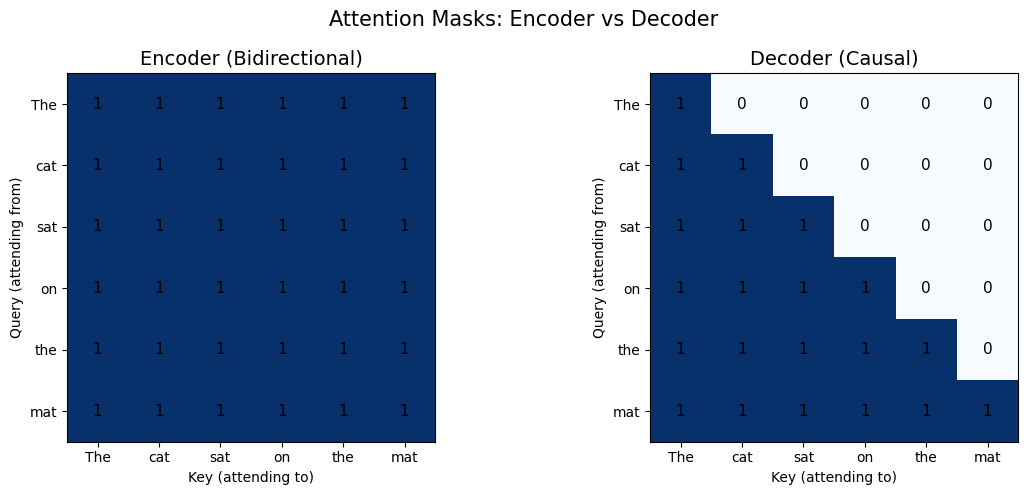

=> In the decoder, each token can only attend to itself and earlier tokens.
   This is what makes autoregressive generation possible.


In [17]:
seq_len = 6
words = ['The', 'cat', 'sat', 'on', 'the', 'mat']

# Encoder: full attention (all ones)
encoder_mask = torch.ones(seq_len, seq_len)

# Decoder: causal mask (lower triangle)
decoder_mask = torch.tril(torch.ones(seq_len, seq_len))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mask, title in [(axes[0], encoder_mask, 'Encoder (Bidirectional)'),
                         (axes[1], decoder_mask, 'Decoder (Causal)')]:
    ax.imshow(mask, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title, fontsize=14)
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(words, fontsize=10)
    ax.set_yticklabels(words, fontsize=10)
    ax.set_xlabel('Key (attending to)')
    ax.set_ylabel('Query (attending from)')
    for i in range(seq_len):
        for j in range(seq_len):
            ax.text(j, i, int(mask[i, j].item()), ha='center', va='center', fontsize=11)

plt.suptitle('Attention Masks: Encoder vs Decoder', fontsize=15)
plt.tight_layout()
plt.show()

print('=> In the decoder, each token can only attend to itself and earlier tokens.')
print('   This is what makes autoregressive generation possible.')

Let's also see the effect of causal masking on the attention weights from Exercise 2.

In [18]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """Same as Exercise 2."""
    d_k = Q.size(-1)
    # SOLUTION
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    attention_weights = F.softmax(scores, dim=-1)
    output = torch.matmul(attention_weights, V)
    return output, attention_weights

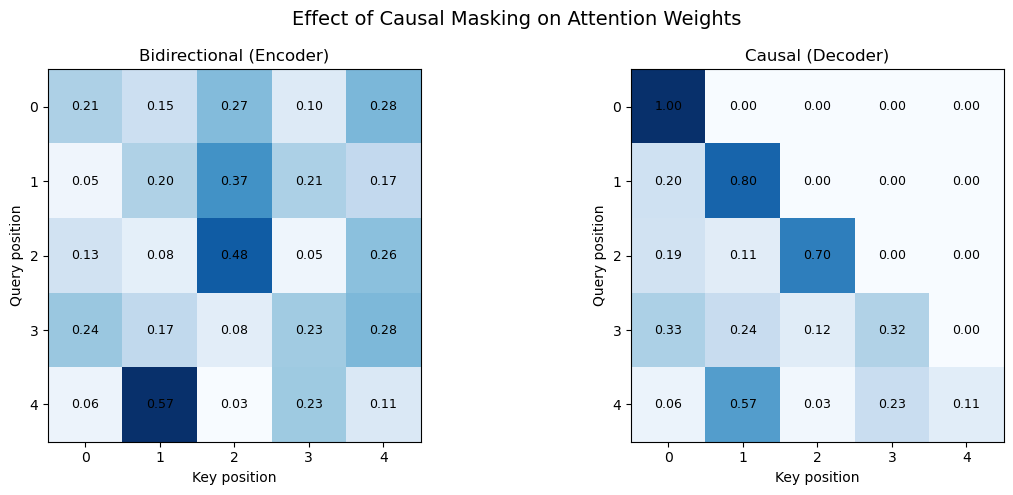

=> The upper triangle becomes zero, no information flows from future to past.


In [19]:
# Compare bidirectional vs causal attention weights on the same Q, K, V
torch.manual_seed(42)
seq_len = 5
d_k = 8

Q = torch.randn(1, seq_len, d_k)
K = torch.randn(1, seq_len, d_k)
V = torch.randn(1, seq_len, d_k)

_, attn_bidir = scaled_dot_product_attention(Q, K, V)

causal_mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0)
_, attn_causal = scaled_dot_product_attention(Q, K, V, mask=causal_mask)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, attn, title in [(axes[0], attn_bidir, 'Bidirectional (Encoder)'),
                         (axes[1], attn_causal, 'Causal (Decoder)')]:
    ax.imshow(attn[0].detach().numpy(), cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')
    for i in range(seq_len):
        for j in range(seq_len):
            ax.text(j, i, f'{attn[0,i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.suptitle('Effect of Causal Masking on Attention Weights', fontsize=14)
plt.tight_layout()
plt.show()

print('=> The upper triangle becomes zero, no information flows from future to past.')

# **2. Load a Pretrained GPT-2 Model**

GPT-2 (Radford et al., 2019) is a decoder-only Transformer trained on a large web corpus. The smallest version has **124M parameters**, 12 layers, 12 attention heads, and `d_model = 768`.

We load it using HuggingFace's `transformers` library. The model was trained on **next-token prediction**, nothing else! Yet it can generate coherent paragraphs, answer questions, summarize text, etc.

In [20]:
# Load the pretrained GPT-2 model and tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2', output_attentions=True).to(device)
model.eval()

num_params = sum(p.numel() for p in model.parameters())
print(f"Model: GPT-2")
print(f"Parameters: {num_params:,}")
print(f"Layers: {model.config.n_layer}")
print(f"Attention heads: {model.config.n_head}")
print(f"d_model: {model.config.n_embd}")
print(f"Vocabulary size: {model.config.vocab_size}")
print(f"Max context length: {model.config.n_positions}")

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 13631.33it/s]


Model: GPT-2
Parameters: 124,439,808
Layers: 12
Attention heads: 12
d_model: 768
Vocabulary size: 50257
Max context length: 1024


# **3. Tokenization: How GPT-2 Sees Text**

GPT-2 uses **Byte-Pair Encoding (BPE)**, a subword tokenizer that splits text into frequent subword units. This is more efficient than character-level (too many tokens) or word-level (too large vocabulary, can't handle unseen words).

Examples:
- Common words stay whole: `"the"` → `["the"]`
- Rare words get split: `"tokenization"` → `["token", "ization"]`
- Very rare words split further: `"Pneumonoultramicroscopicsilicovolcanoconiosis"` → many pieces

**Task:** Explore how different texts get tokenized.

In [21]:
# Tokenize some example texts
examples = [
    "Hello world",
    "The cat sat on the mat",
    "Artificial intelligence is transforming the world",
    "Pneumonoultramicroscopicsilicovolcanoconiosis",
    "Bonjour le monde",  # French
    "def fibonacci(n):\n    if n <= 1:\n        return n",  # Code
]

for text in examples:
    token_ids = tokenizer.encode(text)
    tokens = [tokenizer.decode([tid]) for tid in token_ids]
    print(f"Text:    '{text}'")
    print(f"Tokens:  {tokens}")
    print(f"IDs:     {token_ids}")
    print(f"Count:   {len(token_ids)} tokens")
    print()

Text:    'Hello world'
Tokens:  ['Hello', ' world']
IDs:     [15496, 995]
Count:   2 tokens

Text:    'The cat sat on the mat'
Tokens:  ['The', ' cat', ' sat', ' on', ' the', ' mat']
IDs:     [464, 3797, 3332, 319, 262, 2603]
Count:   6 tokens

Text:    'Artificial intelligence is transforming the world'
Tokens:  ['Art', 'ificial', ' intelligence', ' is', ' transforming', ' the', ' world']
IDs:     [8001, 9542, 4430, 318, 25449, 262, 995]
Count:   7 tokens

Text:    'Pneumonoultramicroscopicsilicovolcanoconiosis'
Tokens:  ['P', 'neum', 'on', 'oult', 'ram', 'icro', 'sc', 'op', 'ics', 'ilic', 'ov', 'ol', 'can', 'ocon', 'iosis']
IDs:     [47, 25668, 261, 25955, 859, 2500, 1416, 404, 873, 41896, 709, 349, 5171, 36221, 42960]
Count:   15 tokens

Text:    'Bonjour le monde'
Tokens:  ['Bon', 'j', 'our', ' le', ' m', 'onde']
IDs:     [20682, 73, 454, 443, 285, 14378]
Count:   6 tokens

Text:    'def fibonacci(n):
    if n <= 1:
        return n'
Tokens:  ['def', ' fib', 'on', 'acci', '(', 'n',

**Question:** Why does `" cat"` have a leading space in the token? (Hint: BPE encodes spaces as part of tokens so that tokenization is reversible.)

# **4. Next-Token Prediction: Looking at the Logits**

GPT-2 was trained with a single objective: given all previous tokens, predict the probability distribution over the **next token**.

At each position, the model outputs a vector of **logits** (one per vocabulary token). Applying softmax gives us probabilities.

**Task:** Feed a prompt to GPT-2, extract the logits for the last position, and inspect the top predicted next tokens.

In [22]:
prompt = "The capital of France is"

# Tokenize the prompt
input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
print(f"Prompt: '{prompt}'")
print(f"Token IDs: {input_ids[0].tolist()}")
print(f"Tokens: {[tokenizer.decode([tid]) for tid in input_ids[0]]}")

# Forward pass
with torch.no_grad():
    outputs = model(input_ids)
    logits = outputs.logits  # shape: (1, seq_len, vocab_size)

print(f"\nLogits shape: {logits.shape}")
print(f"  -> 1 batch, {logits.shape[1]} positions, {logits.shape[2]} vocabulary size")

Prompt: 'The capital of France is'
Token IDs: [464, 3139, 286, 4881, 318]
Tokens: ['The', ' capital', ' of', ' France', ' is']

Logits shape: torch.Size([1, 5, 50257])
  -> 1 batch, 5 positions, 50257 vocabulary size


In [23]:
# Get the logits for the LAST position (the prediction for the next token)
last_logits = logits[0, -1, :]  # shape: (vocab_size,)

# SOLUTION
probs = F.softmax(last_logits, dim=-1)
top_probs, top_indices = torch.topk(probs, 10)

print(f"Top 10 predicted next tokens for '{prompt} ___':\n")
for i in range(10):
    token = tokenizer.decode([top_indices[i].item()])
    prob = top_probs[i].item()
    print(f"  {token:15s}  probability: {prob:.4f}  ({prob*100:.1f}%)")

Top 10 predicted next tokens for 'The capital of France is ___':

   the             probability: 0.0846  (8.5%)
   now             probability: 0.0479  (4.8%)
   a               probability: 0.0462  (4.6%)
   France          probability: 0.0324  (3.2%)
   Paris           probability: 0.0322  (3.2%)
   in              probability: 0.0266  (2.7%)
   also            probability: 0.0264  (2.6%)
   not             probability: 0.0238  (2.4%)
   home            probability: 0.0233  (2.3%)
   still           probability: 0.0155  (1.6%)


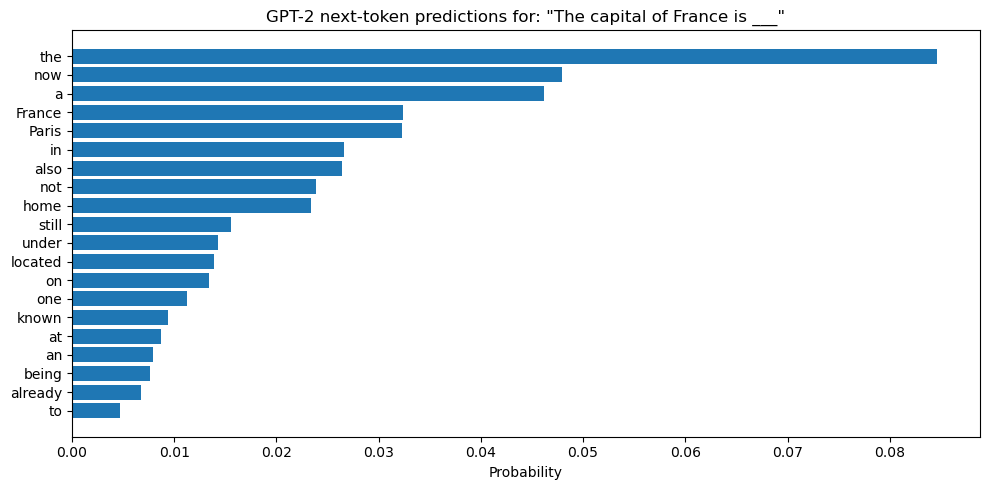

In [24]:
# Visualize the top-20 predictions as a bar chart
top_probs, top_indices = torch.topk(F.softmax(last_logits, dim=-1), 20)
top_tokens = [tokenizer.decode([idx.item()]).strip() for idx in top_indices]

plt.figure(figsize=(10, 5))
plt.barh(range(19, -1, -1), top_probs.cpu().numpy())
plt.yticks(range(19, -1, -1), top_tokens)
plt.xlabel('Probability')
plt.title(f'GPT-2 next-token predictions for: "{prompt} ___"')
plt.tight_layout()
plt.show()

**Task:** Try different prompts and observe how the model's predictions change. Try:
- `"The meaning of life is"`
- `"def hello_world():"`
- `"In 1969, the first man on the moon was"`

In [25]:
# SOLUTION, try different prompts
test_prompts = [
    "The meaning of life is",
    "def hello_world():",
    "In 1969, the first man on the moon was",
]

for prompt in test_prompts:
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        logits = model(input_ids).logits[0, -1, :]
    probs = F.softmax(logits, dim=-1)
    top_probs, top_indices = torch.topk(probs, 5)
    
    print(f"'{prompt} ___'")
    for i in range(5):
        token = tokenizer.decode([top_indices[i].item()])
        print(f"    {token:15s} ({top_probs[i].item()*100:.1f}%)")
    print()

'The meaning of life is ___'
     not            (10.9%)
     to             (8.3%)
     the            (5.1%)
     that           (4.8%)
     a              (4.0%)

'def hello_world(): ___'
    
               (17.4%)
     hello          (6.5%)
     Hello          (5.5%)
     #              (3.0%)
     print          (2.5%)

'In 1969, the first man on the moon was ___'
     Neil           (7.5%)
     named          (4.1%)
     a              (2.7%)
     the            (2.0%)
     born           (1.6%)



# **5. Text Generation: Decoding Strategies**

To generate text, we repeatedly:
1. Feed the current sequence to the model
2. Get the probability distribution over the next token
3. **Select** the next token (this is the decoding strategy)
4. Append and repeat

Different decoding strategies:

| Strategy | Description |
|----------|-------------|
| **Greedy** | Always pick the most likely token. Deterministic but repetitive. |
| **Temperature** | Divide logits by T before softmax. T<1 = sharper (more confident), T>1 = flatter (more random). |
| **Top-k** | Only sample from the k most likely tokens. |
| **Top-p (nucleus)** | Only sample from the smallest set of tokens whose cumulative probability exceeds p. |

**Task:** Implement a generation function that supports these strategies.

In [26]:
@torch.no_grad()
def generate(model, tokenizer, prompt, max_new_tokens=50, temperature=1.0, top_k=None, top_p=None):
    """
    Generate text from a prompt using GPT-2.
    
    Args:
        model: GPT-2 model
        tokenizer: GPT-2 tokenizer
        prompt: seed text (string)
        max_new_tokens: how many tokens to generate
        temperature: temperature for sampling (1.0 = normal)
        top_k: if set, only sample from top-k tokens
        top_p: if set, only sample from tokens whose cumulative prob < p (nucleus sampling)
    Returns:
        generated text (string)
    """
    model.eval()
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
    
    for _ in range(max_new_tokens):
        # SOLUTION
        # Step 1: Crop to last 1024 tokens
        x = input_ids[:, -1024:]
        
        # Step 2: Forward pass
        outputs = model(x)
        logits = outputs.logits[:, -1, :]
        
        # Step 3: Apply temperature
        logits = logits / temperature
        
        # Step 4: Top-k filtering
        if top_k is not None:
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[:, [-1]]] = -float('inf')
        
        # Step 5: Top-p (nucleus) filtering
        if top_p is not None:
            sorted_logits, sorted_indices = torch.sort(logits, descending=True)
            cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
            remove_mask = cumulative_probs - F.softmax(sorted_logits, dim=-1) >= top_p
            sorted_logits[remove_mask] = -float('inf')
            logits = sorted_logits.scatter(1, sorted_indices, sorted_logits)
        
        # Step 6: Sample
        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        
        # Step 7: Append
        input_ids = torch.cat([input_ids, next_token], dim=1)
    
    return tokenizer.decode(input_ids[0].tolist())

In [27]:
prompt = "In a world where artificial intelligence has become"

print("=" * 70)
print("GREEDY (temperature=0.01):")
print("=" * 70)
print(generate(model, tokenizer, prompt, max_new_tokens=60, temperature=0.01))

print("\n" + "=" * 70)
print("NORMAL (temperature=1.0):")
print("=" * 70)
print(generate(model, tokenizer, prompt, max_new_tokens=60, temperature=1.0))

print("\n" + "=" * 70)
print("CREATIVE (temperature=1.5):")
print("=" * 70)
print(generate(model, tokenizer, prompt, max_new_tokens=60, temperature=1.5))

GREEDY (temperature=0.01):
In a world where artificial intelligence has become a reality, it's important to understand how it works.

The first step is to understand how it works.

The second step is to understand how it works.

The third step is to understand how it works.

The fourth step is to understand how it works.

NORMAL (temperature=1.0):
In a world where artificial intelligence has become an integral part of other psychobiological technologies, we should at least be cautious about the influence of brain matter.

What's Going On?

Let's take a quick look at a popular question we used to justify electrons being lost in space: One way to consider the use of electricity

CREATIVE (temperature=1.5):
In a world where artificial intelligence has become the currency subject wererie illustré surfully appropriated 2008 alact own representation methods adul castle shutł sprung CH beating Column projected woes compliance vet back relay ultimate pictures phones inferior draft territory Si

In [28]:
print("=" * 70)
print("TOP-K (k=10, temperature=0.8):")
print("=" * 70)
print(generate(model, tokenizer, prompt, max_new_tokens=60, temperature=0.8, top_k=10))

print("\n" + "=" * 70)
print("TOP-P / NUCLEUS (p=0.9, temperature=0.8):")
print("=" * 70)
print(generate(model, tokenizer, prompt, max_new_tokens=60, temperature=0.8, top_p=0.9))

TOP-K (k=10, temperature=0.8):
In a world where artificial intelligence has become so pervasive, the world's greatest threat is to come to grips with the fact that it is not just a matter of technology, but also a fact of the human condition, a fact that will be increasingly difficult to ignore.

The human brain is a machine, and it has to be able

TOP-P / NUCLEUS (p=0.9, temperature=0.8):
In a world where artificial intelligence has become the dominant approach to social science research, the early results from the initial research are hard to come by. But what we know, for the first time, is that it is possible to use this technology to make a more accurate prediction about human behavior, and to reduce the time and effort required for scientists


**Question:** Run the greedy generation multiple times. Do you always get the same output? Why? Now run the temperature=1.0 generation multiple times. What changes?

# **6. Visualizing the Effect of Temperature**

Temperature controls how "spread out" the probability distribution is. Let's visualize this on the same prompt.

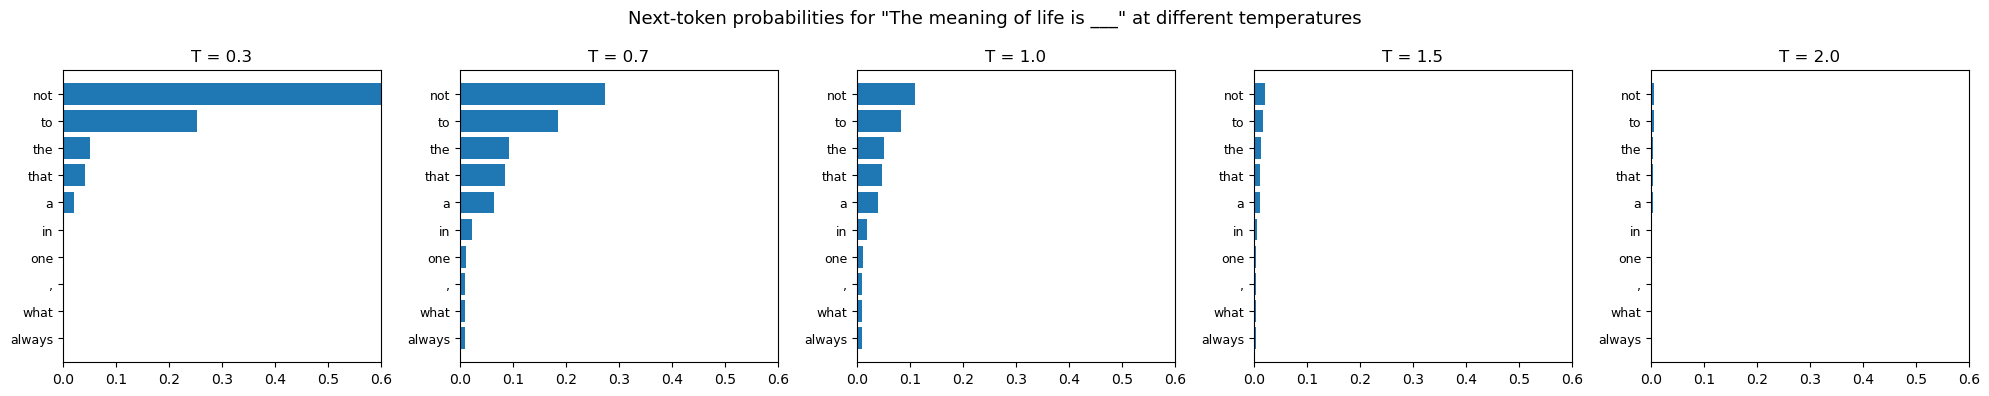

=> Low T: model is very confident (peaky distribution)
   High T: model spreads probability more evenly (flatter distribution)


In [29]:
prompt = "The meaning of life is"
input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

with torch.no_grad():
    logits = model(input_ids).logits[0, -1, :]  # raw logits for last position

temperatures = [0.3, 0.7, 1.0, 1.5, 2.0]
fig, axes = plt.subplots(1, len(temperatures), figsize=(20, 4))

for ax, temp in zip(axes, temperatures):
    probs = F.softmax(logits / temp, dim=-1)
    top_probs, top_idx = torch.topk(probs, 10)
    tokens = [tokenizer.decode([i.item()]).strip() for i in top_idx]
    
    ax.barh(range(9, -1, -1), top_probs.cpu().numpy())
    ax.set_yticks(range(9, -1, -1))
    ax.set_yticklabels(tokens, fontsize=9)
    ax.set_title(f'T = {temp}')
    ax.set_xlim(0, 0.6)

plt.suptitle(f'Next-token probabilities for "{prompt} ___" at different temperatures', fontsize=13)
plt.tight_layout()
plt.show()

print('=> Low T: model is very confident (peaky distribution)')
print('   High T: model spreads probability more evenly (flatter distribution)')

# **7. Visualizing Attention Patterns in GPT-2**

GPT-2 has 12 layers, each with 12 attention heads. Let's see what patterns emerge in the attention weights of the trained model.

**Task:** Feed a sentence to GPT-2 and visualize the attention weights from different layers and heads.

In [30]:
sentence = "The cat sat on the mat because it was tired"
input_ids = tokenizer.encode(sentence, return_tensors='pt').to(device)
tokens = [tokenizer.decode([tid]) for tid in input_ids[0]]

with torch.no_grad():
    outputs = model(input_ids)

# outputs.attentions is a tuple of (num_layers) tensors, each of shape (batch, num_heads, seq_len, seq_len)
print(f"Number of layers: {len(outputs.attentions)}")
print(f"Attention shape per layer: {outputs.attentions[0].shape}")
print(f"Tokens: {tokens}")

Number of layers: 12
Attention shape per layer: torch.Size([1, 12, 10, 10])
Tokens: ['The', ' cat', ' sat', ' on', ' the', ' mat', ' because', ' it', ' was', ' tired']


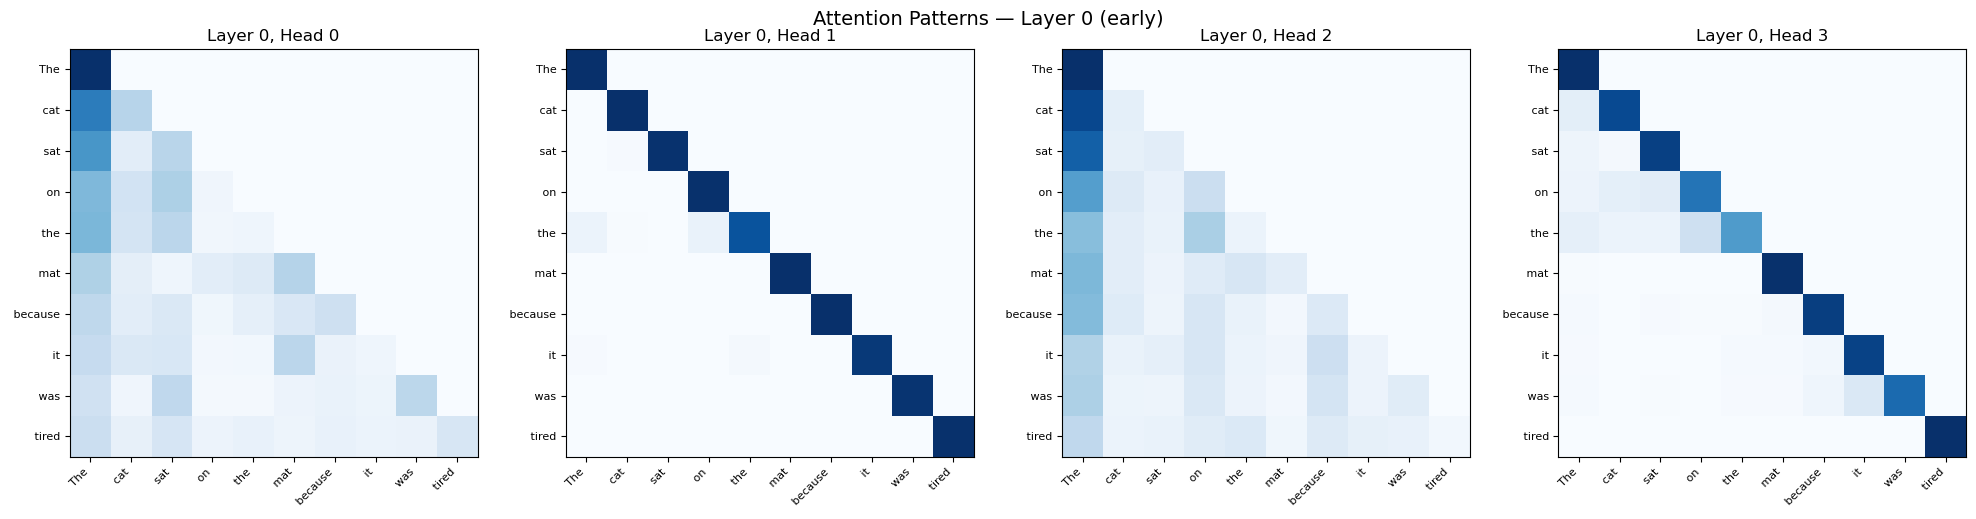

In [31]:
# Visualize attention from Layer 0 (early layer), 4 heads
layer_idx = 0
attn = outputs.attentions[layer_idx][0]  # (num_heads, seq_len, seq_len)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for h in range(4):
    ax = axes[h]
    ax.imshow(attn[h].cpu().numpy(), cmap='Blues')
    ax.set_title(f'Layer {layer_idx}, Head {h}')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
plt.suptitle(f'Attention Patterns, Layer {layer_idx} (early)', fontsize=14)
plt.tight_layout()
plt.show()

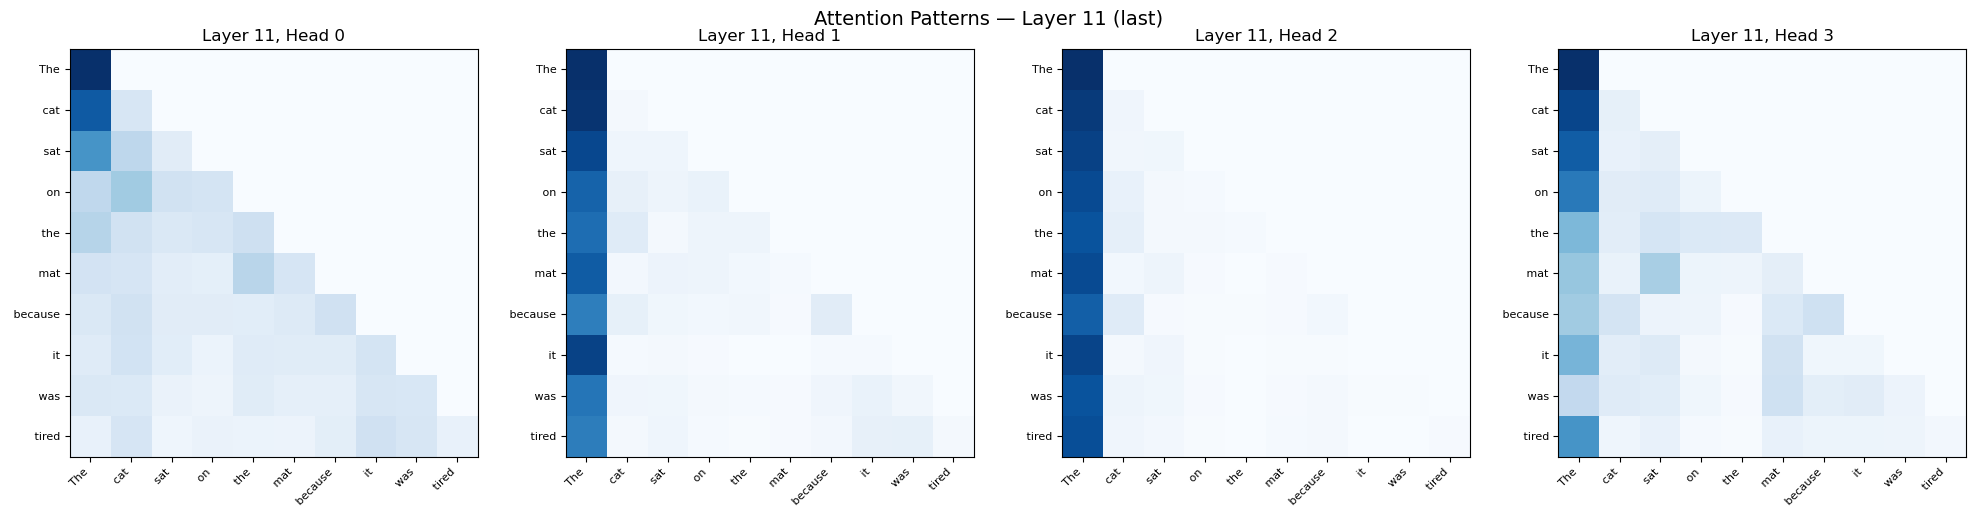

=> Notice: all attention maps are lower-triangular (causal masking)!
   Early layers often show local patterns (neighboring tokens).
   Later layers show more semantic patterns (long-range dependencies).


In [32]:
# Visualize attention from Layer 11 (last layer), 4 heads
layer_idx = 11
attn = outputs.attentions[layer_idx][0]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for h in range(4):
    ax = axes[h]
    ax.imshow(attn[h].cpu().numpy(), cmap='Blues')
    ax.set_title(f'Layer {layer_idx}, Head {h}')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
plt.suptitle(f'Attention Patterns, Layer {layer_idx} (last)', fontsize=14)
plt.tight_layout()
plt.show()

print('=> Notice: all attention maps are lower-triangular (causal masking)!')
print('   Early layers often show local patterns (neighboring tokens).')
print('   Later layers show more semantic patterns (long-range dependencies).')

**Task:** Look at the attention weights for the word `"it"`. Which tokens does it attend to most? Does it attend to `"cat"` (the pronoun referent)? Try different heads and layers to find one that captures this coreference.

In [33]:
# SOLUTION
it_pos = tokens.index(' it')
print(f"Position of 'it': {it_pos}")
print(f"Tokens: {list(enumerate(tokens))}\n")

for layer_idx in [0, 5, 11]:
    attn = outputs.attentions[layer_idx][0]  # (num_heads, seq_len, seq_len)
    it_attn = attn[:, it_pos, :]              # (num_heads, seq_len)
    
    print(f"--- Layer {layer_idx} ---")
    for head in range(12):
        top_vals, top_pos = torch.topk(it_attn[head], 3)
        top_tokens = [(tokens[p.item()], f'{v.item():.3f}') for v, p in zip(top_vals, top_pos)]
        # Check if 'cat' is in the top attended tokens
        cat_weight = it_attn[head][tokens.index(' cat')].item()
        marker = ' <-- attends to cat!' if cat_weight > 0.15 else ''
        print(f"  Head {head:2d}: {top_tokens}  (cat weight: {cat_weight:.3f}){marker}")
    print()

Position of 'it': 7
Tokens: [(0, 'The'), (1, ' cat'), (2, ' sat'), (3, ' on'), (4, ' the'), (5, ' mat'), (6, ' because'), (7, ' it'), (8, ' was'), (9, ' tired')]

--- Layer 0 ---
  Head  0: [(' mat', '0.283'), ('The', '0.248'), (' sat', '0.155')]  (cat weight: 0.146)
  Head  1: [(' it', '0.961'), (' the', '0.021'), ('The', '0.008')]  (cat weight: 0.003)
  Head  2: [('The', '0.315'), (' because', '0.212'), (' on', '0.159')]  (cat weight: 0.067)
  Head  3: [(' it', '0.928'), (' because', '0.030'), (' mat', '0.014')]  (cat weight: 0.001)
  Head  4: [(' because', '0.335'), (' it', '0.274'), ('The', '0.134')]  (cat weight: 0.039)
  Head  5: [(' it', '0.844'), ('The', '0.095'), (' cat', '0.032')]  (cat weight: 0.032)
  Head  6: [(' cat', '0.236'), (' mat', '0.225'), ('The', '0.206')]  (cat weight: 0.236) <-- attends to cat!
  Head  7: [(' because', '0.378'), (' it', '0.264'), (' the', '0.102')]  (cat weight: 0.016)
  Head  8: [(' the', '0.354'), (' it', '0.278'), ('The', '0.125')]  (cat weig

# **8. From GPT-2 to Modern LLMs**

GPT-2 is the ancestor of modern LLMs. The core idea hasn't changed much, it's still a **stack of decoder blocks with causal self-attention, trained to predict the next token**. What has changed is scale and refinement:

| Feature | GPT-2 (2019) | GPT-3 (2020) | LLaMA 2 70B (2023) | GPT-4 (2023) |
|---------|-------------|-------------|-------------------|-------------|
| Parameters | 124M – 1.5B | 175B | 70B | ~1.8T (estimated) |
| Layers | 12 – 48 | 96 | 80 | unknown |
| Context length | 1024 | 2048 | 4096 | 128K |
| Tokenizer | BPE (50K) | BPE (50K) | SentencePiece (32K) | BPE (100K) |
| Training data | 40GB (WebText) | 570GB | 2TB | unknown |

**Key innovations since GPT-2:**
- **Instruction tuning**, fine-tuning on instruction/response pairs so the model follows directions
- **RLHF** (Reinforcement Learning from Human Feedback), aligning the model with human preferences
- **RoPE** (Rotary Position Embeddings), better positional encoding for longer contexts
- **GQA** (Grouped Query Attention), more efficient multi-head attention
- **SwiGLU** activations, better than ReLU in the FFN

But the fundamental architecture you explored today, embedding → causal self-attention → FFN → next-token prediction, remains the same.

**Questions to think about:**
1. GPT-2 was only trained on next-token prediction. How can it "know" facts about the world?
2. What happens when you give GPT-2 a prompt in a language it wasn't primarily trained on (e.g., French, Chinese)?
3. Why is top-p (nucleus) sampling generally preferred over top-k in practice?
4. How does the number of parameters relate to what the model can "memorize" vs. "generalize"?